In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/user/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
data=pd.read_csv("noshowappointments.csv")

In [3]:
numeric_df = data.select_dtypes(include='number')
numeric_df

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
0,2.987250e+13,5642903,62,0,1,0,0,0,0
1,5.589978e+14,5642503,56,0,0,0,0,0,0
2,4.262962e+12,5642549,62,0,0,0,0,0,0
3,8.679512e+11,5642828,8,0,0,0,0,0,0
4,8.841186e+12,5642494,56,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,56,0,0,0,0,0,1
110523,3.596266e+12,5650093,51,0,0,0,0,0,1
110524,1.557663e+13,5630692,21,0,0,0,0,0,1
110525,9.213493e+13,5630323,38,0,0,0,0,0,1


In [4]:

summary_data = print(data.describe(include="all"))
summary_data

           PatientId  AppointmentID  Gender          ScheduledDay  \
count   1.105270e+05   1.105270e+05  110527                110527   
unique           NaN            NaN       2                103549   
top              NaN            NaN       F  2016-05-06T07:09:54Z   
freq             NaN            NaN   71840                    24   
mean    1.474963e+14   5.675305e+06     NaN                   NaN   
std     2.560949e+14   7.129575e+04     NaN                   NaN   
min     3.921784e+04   5.030230e+06     NaN                   NaN   
25%     4.172614e+12   5.640286e+06     NaN                   NaN   
50%     3.173184e+13   5.680573e+06     NaN                   NaN   
75%     9.439172e+13   5.725524e+06     NaN                   NaN   
max     9.999816e+14   5.790484e+06     NaN                   NaN   

              AppointmentDay            Age   Neighbourhood    Scholarship  \
count                 110527  110527.000000          110527  110527.000000   
unique         

In [5]:

Q1 = data.select_dtypes(include='number').quantile(0.25)
Q2 = data.select_dtypes(include='number').quantile(0.50)
Q3 = data.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

print(f"Q1(First Quartile):{Q1}, Q2(Second Quartile): {Q2}, and Q3(Third quartile) : {Q3}")
print(f"Inter Quartile Range :{IQR}")

Q1(First Quartile):PatientId        4.172614e+12
AppointmentID    5.640286e+06
Age              1.800000e+01
Scholarship      0.000000e+00
Hipertension     0.000000e+00
Diabetes         0.000000e+00
Alcoholism       0.000000e+00
Handcap          0.000000e+00
SMS_received     0.000000e+00
Name: 0.25, dtype: float64, Q2(Second Quartile): PatientId        3.173184e+13
AppointmentID    5.680573e+06
Age              3.700000e+01
Scholarship      0.000000e+00
Hipertension     0.000000e+00
Diabetes         0.000000e+00
Alcoholism       0.000000e+00
Handcap          0.000000e+00
SMS_received     0.000000e+00
Name: 0.5, dtype: float64, and Q3(Third quartile) : PatientId        9.439172e+13
AppointmentID    5.725524e+06
Age              5.500000e+01
Scholarship      0.000000e+00
Hipertension     0.000000e+00
Diabetes         0.000000e+00
Alcoholism       0.000000e+00
Handcap          0.000000e+00
SMS_received     1.000000e+00
Name: 0.75, dtype: float64
Inter Quartile Range :PatientId        9.02

In [6]:
data["Age"].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [7]:
Q1 = data["Age"].quantile(0.25)
Q2 = data["Age"].quantile(0.50)
Q3 = data["Age"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1(First Quartile):{Q1}, Q2(Second Quartile): {Q2}, and Q3(Third quartile) : {Q3}")
print(f"Inter Quartile Range :{IQR}")

Q1(First Quartile):18.0, Q2(Second Quartile): 37.0, and Q3(Third quartile) : 55.0
Inter Quartile Range :37.0


In [20]:
#percentage of outsiude quamtile 

iqr_perct= IQR/(Q1+Q2+Q3)
outside = 100-(iqr_perct*100)
print(outside)

66.36363636363637


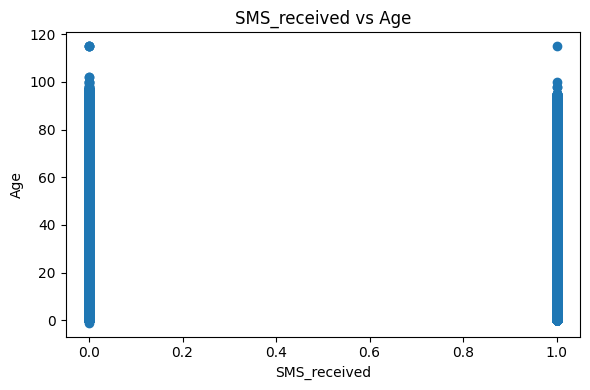

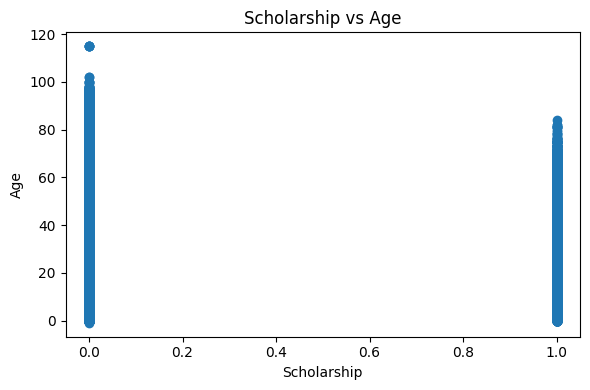

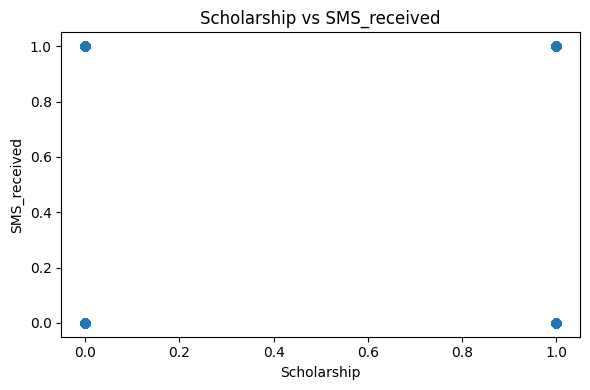

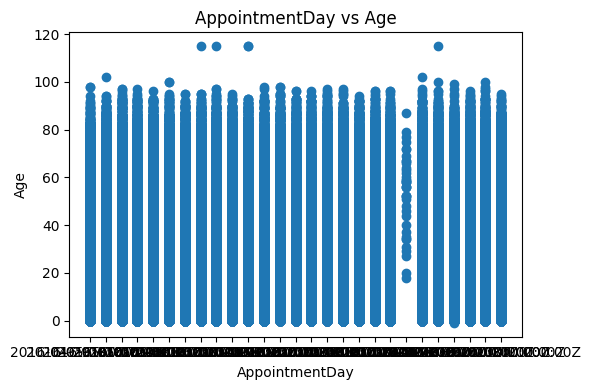

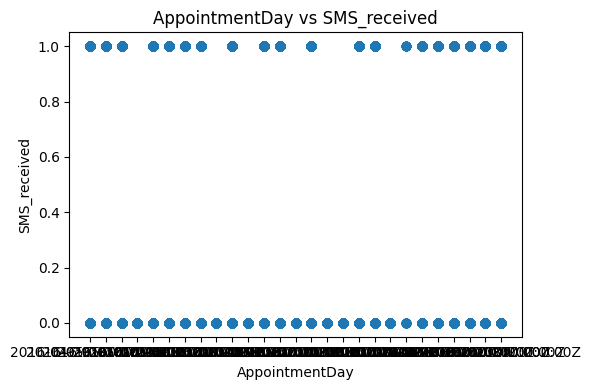

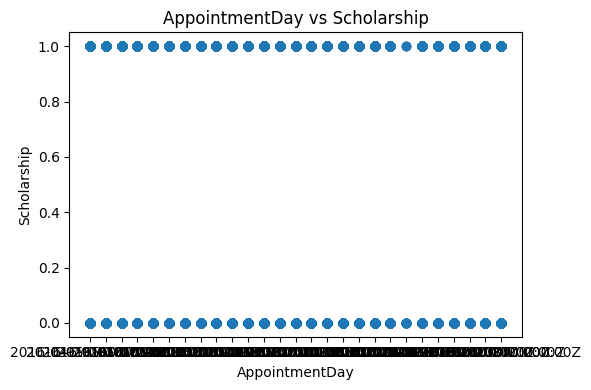

In [8]:
numeric_cols = ["Age" , "SMS_received" , "Scholarship" , "AppointmentDay" ]



for i in range(len(numeric_cols)):
    for j in range(i):

    
      x = numeric_cols[i]
      y = numeric_cols[j]

      plt.figure(figsize=(6,4))
      plt.scatter(data[x], data[y])
      plt.xlabel(x)
      plt.ylabel(y)
      plt.title(f"{x} vs {y}")
      plt.tight_layout()
      plt.show()


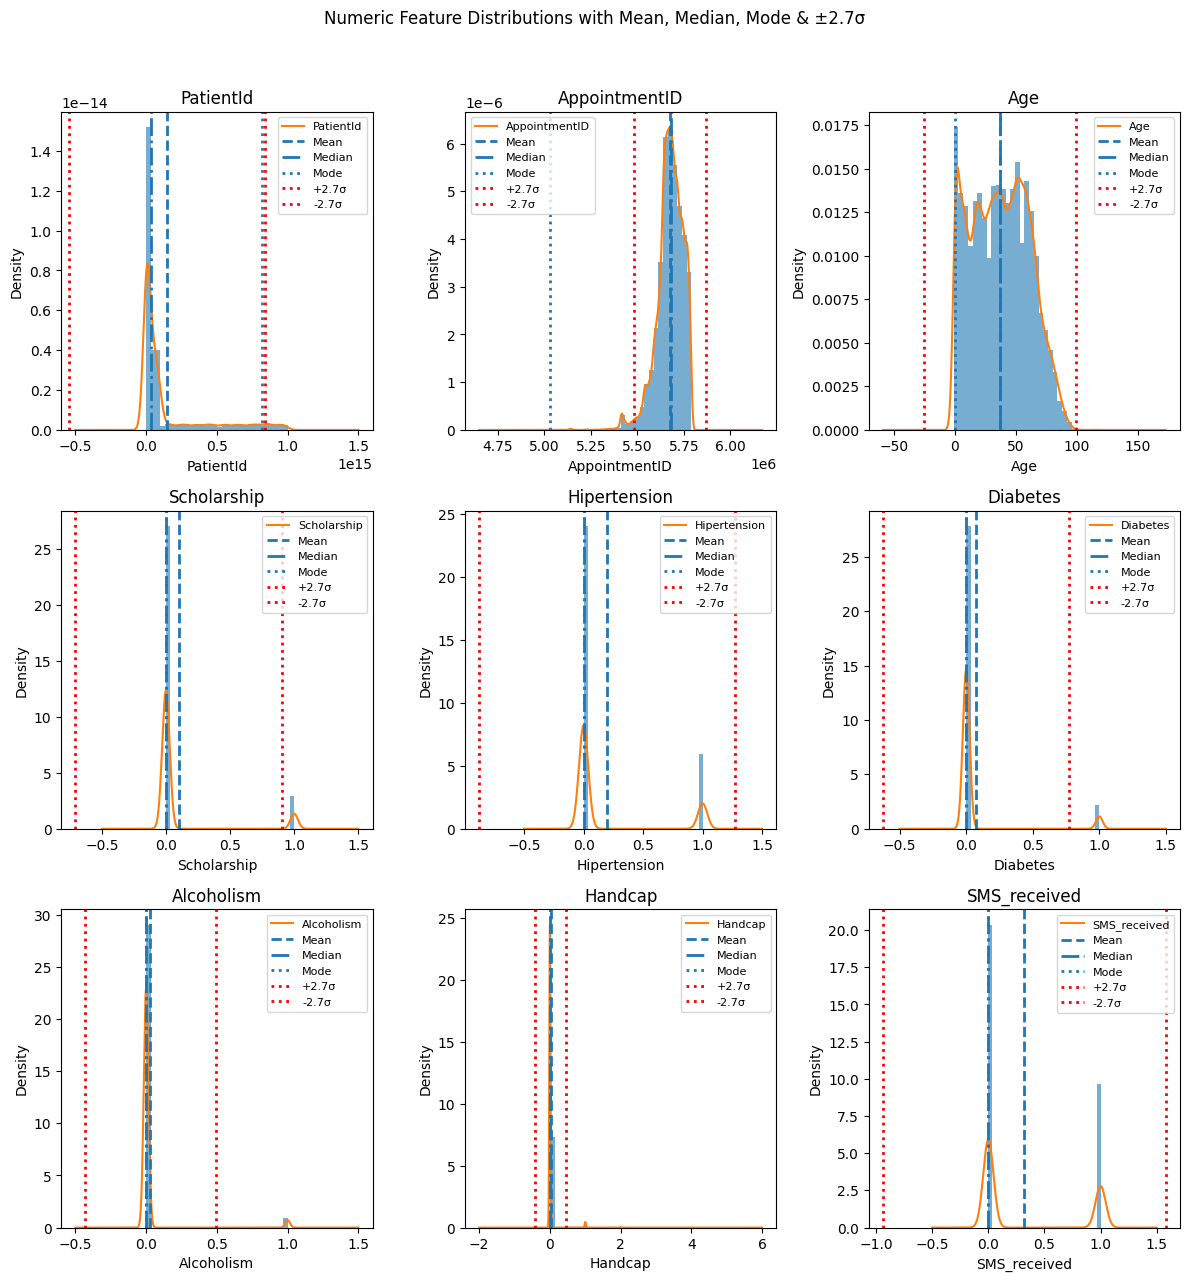

In [9]:
numeric_cols = numeric_df.select_dtypes(include='number')

num_cols = len(numeric_cols.columns)
rows = (num_cols // 3) + 1

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(numeric_cols.columns, 1):
    data_col = numeric_cols[col].dropna()

    mu = data_col.mean()
    median = data_col.median()
    mode = data_col.mode().iloc[0] #.iloc[0] selects the first one from many modes
    sigma = data_col.std(ddof=1) # ddof : Delta Degrees of Freedom

    ucl = mu + 2.7 * sigma
    lcl = mu - 2.7 * sigma

    plt.subplot(rows, 3, i)

    plt.hist(data_col, bins=30, density=True, alpha=0.6)
    data_col.plot(kind='kde')

    plt.axvline(mu, linestyle='--', linewidth=2, label=f"Mean")
    plt.axvline(median, linestyle='-.', linewidth=2, label=f"Median")
    plt.axvline(mode, linestyle=':', linewidth=2, label=f"Mode")
    plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label="+2.7σ")
    plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label="-2.7σ")

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions with Mean, Median, Mode & ±2.7σ", y=1.02)
plt.tight_layout()
plt.show()

<Figure size 1200x1600 with 0 Axes>

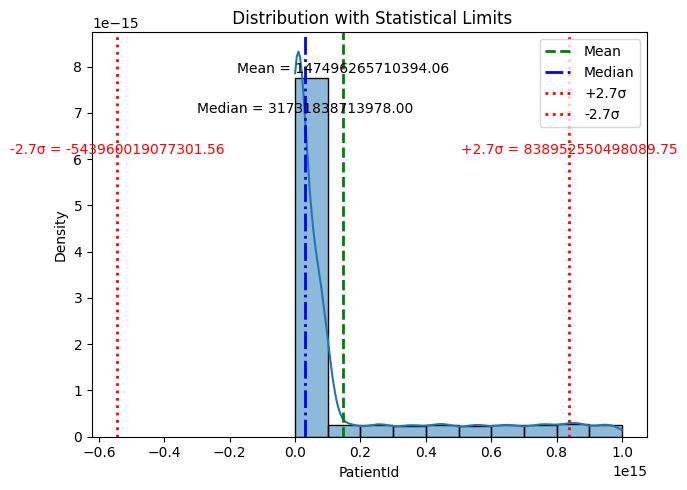

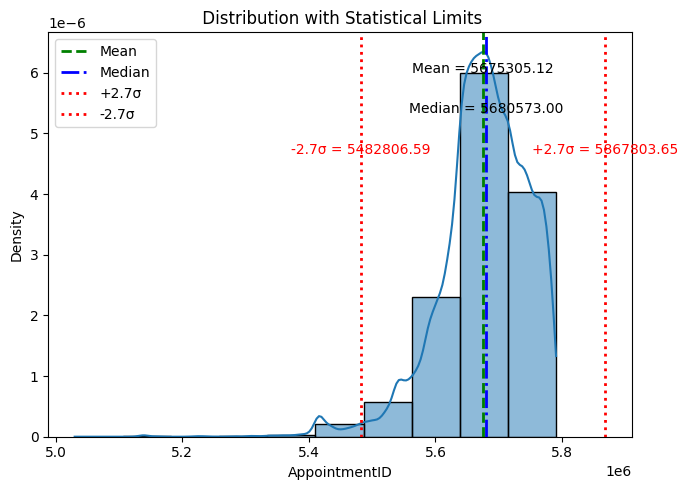

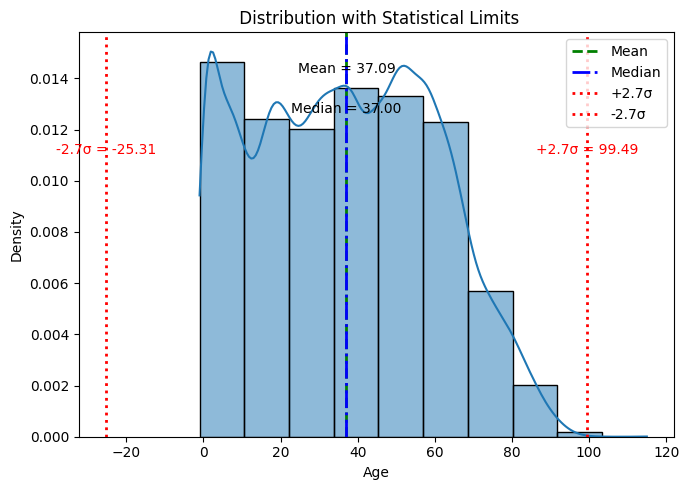

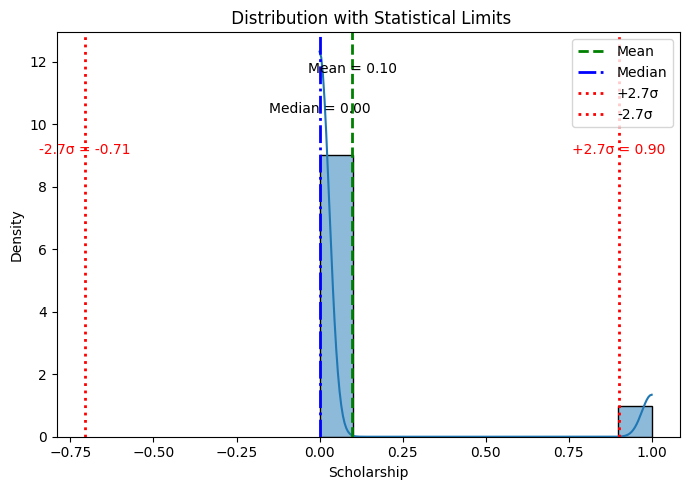

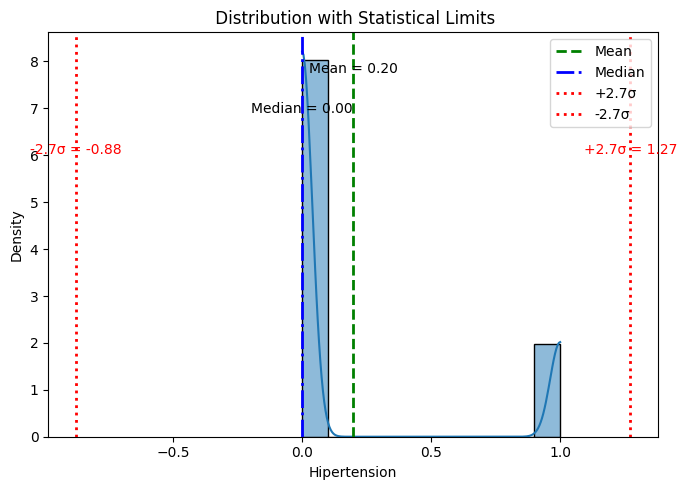

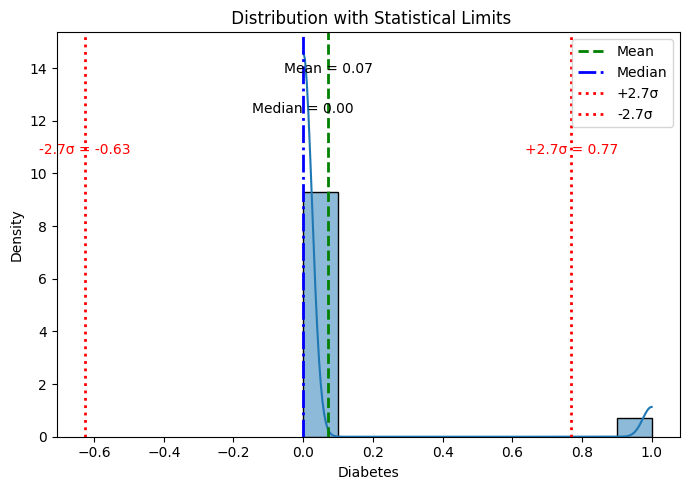

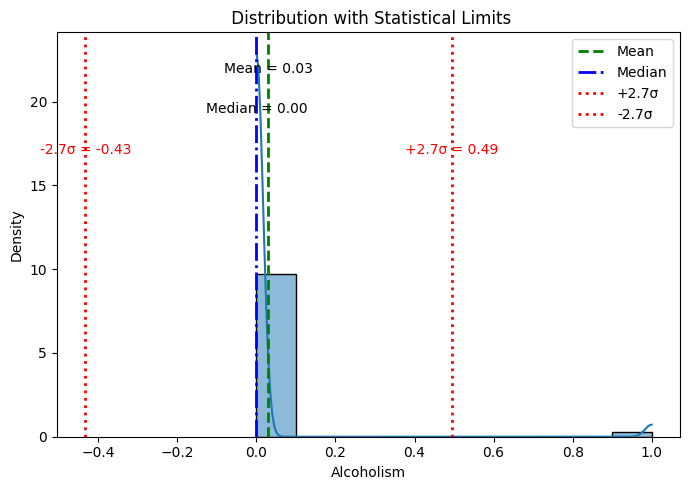

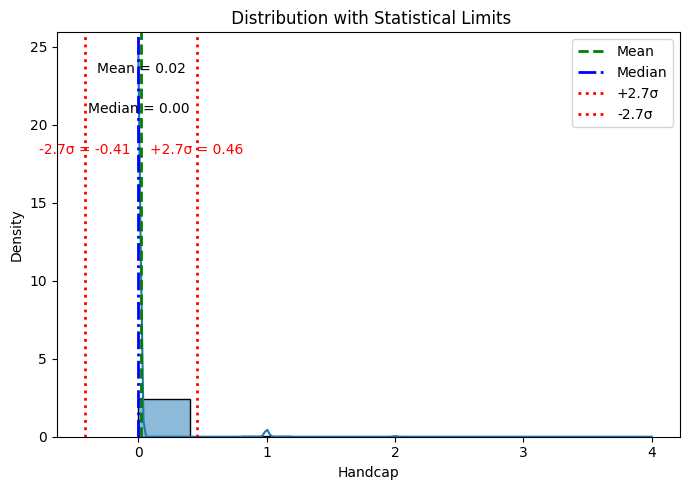

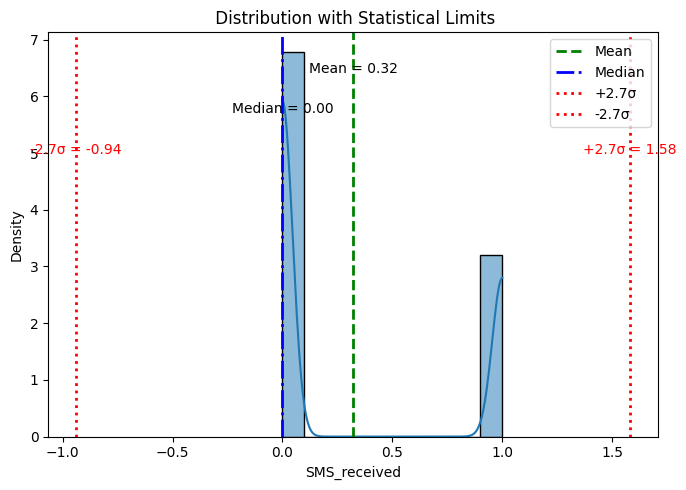

In [11]:
numeric_cols = numeric_df.select_dtypes(include='number')

num_cols = len(numeric_cols.columns)
rows = (num_cols // 3) + 1

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(numeric_cols.columns, 1):
    d= numeric_cols[col].dropna()
    

    mu = d.mean()
    median = d.median()
    sigma = d.std(ddof=1)

    ucl = mu + 2.7 * sigma
    lcl = mu - 2.7 * sigma

    plt.figure(figsize=(7,5))
    sns.histplot(d, bins=10, kde=True, stat="density")

# Reference lines
    plt.axvline(mu, linestyle='--', linewidth=2, label='Mean', color ='green')
    plt.axvline(median, linestyle='-.', linewidth=2, label='Median', color = 'blue')
    plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label='+2.7σ')
    plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label='-2.7σ')

# Numeric labels
    ymax = plt.ylim()[1]
    plt.text(mu, ymax*0.90, f"Mean = {mu:.2f}", ha='center')
    plt.text(median, ymax*0.80, f"Median = {median:.2f}", ha='center')
    plt.text(ucl, ymax*0.70, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
    plt.text(lcl, ymax*0.70, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

    plt.title(" Distribution with Statistical Limits")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    

             Age  SMS_received  Scholarship
No-show                                    
No       3333386         25698         8283
Yes       765936          9784         2578


[]

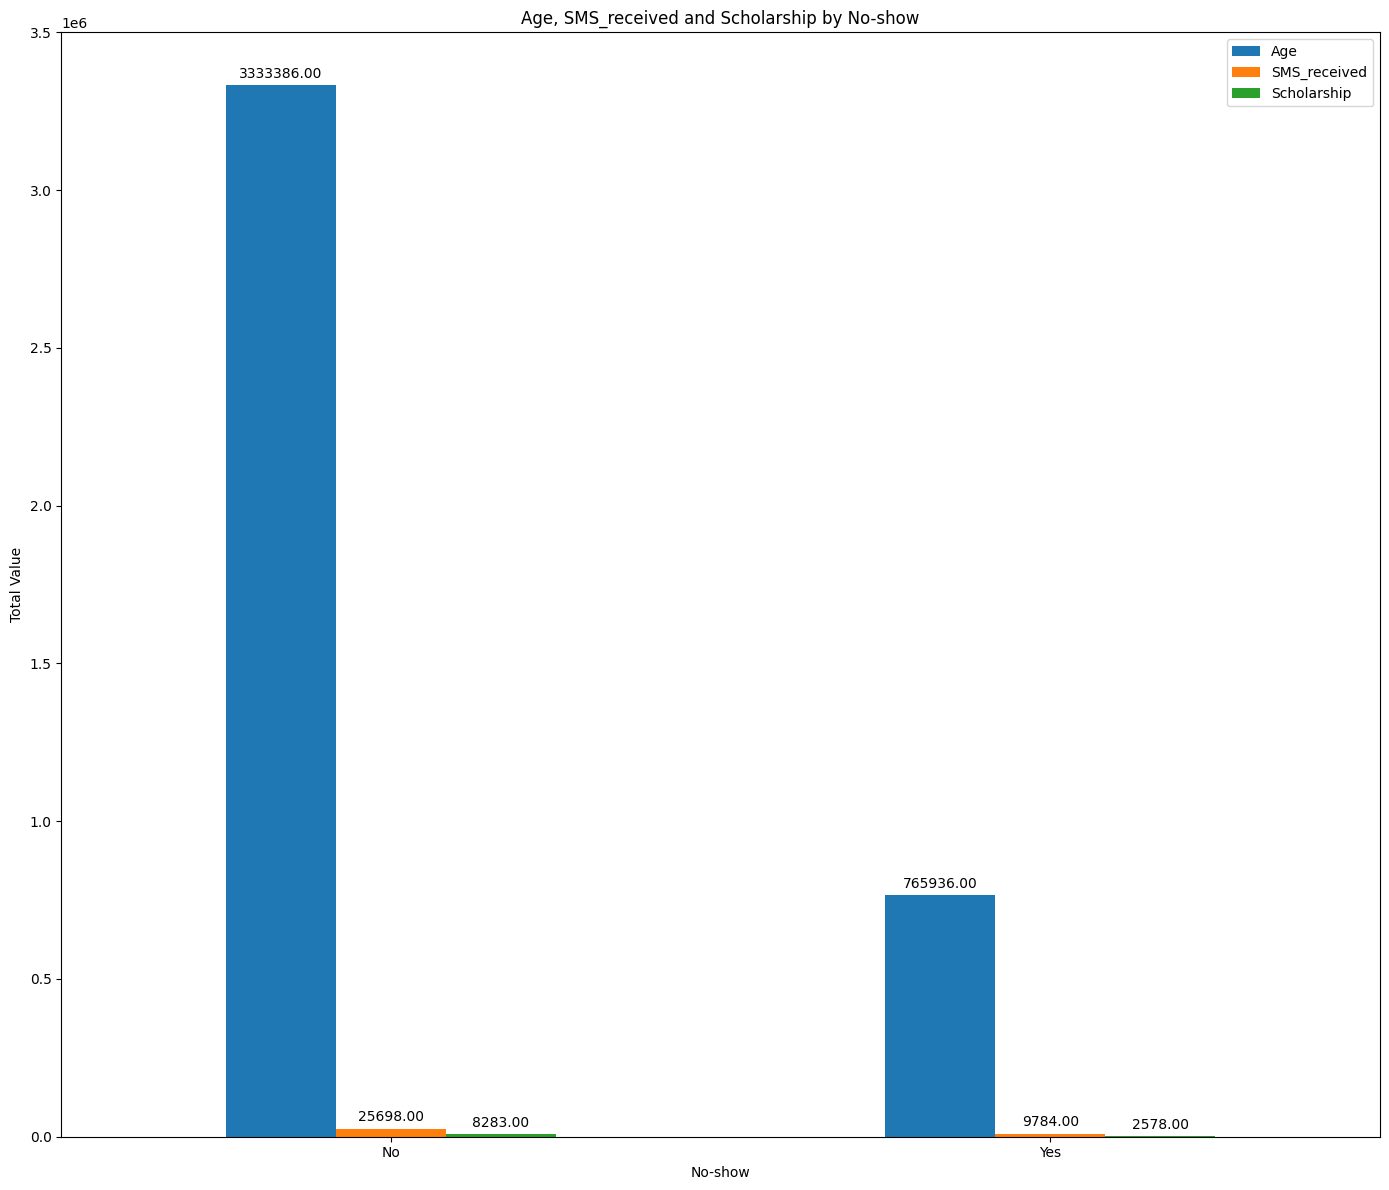

In [12]:
# Plot profit by Category
total_profit = data.groupby('No-show')[['Age', 'SMS_received', 'Scholarship']].sum()
print(total_profit)


ax = total_profit.plot(kind='bar', figsize=(14,12))
plt.title('Age, SMS_received and Scholarship by No-show')
plt.xlabel('No-show')
plt.ylabel('Total Value')
plt.xticks(rotation=0)

for container in ax.containers: # ax.containers refers to a list of container objects that hold groups of artists (graphical elements) created by certain plotting functions
    ax.bar_label(container, fmt='%.2f', padding=3, rotation = 0)

plt.tight_layout()
plt.plot()


In [15]:
grouped=data.groupby("No-show")[["Age","SMS_received","Scholarship"]].mean().reset_index()
grouped_melt=grouped.melt(id_vars="No-show", value_vars=["Age","SMS_received","Scholarship"],var_name='Feature',value_name='Average')

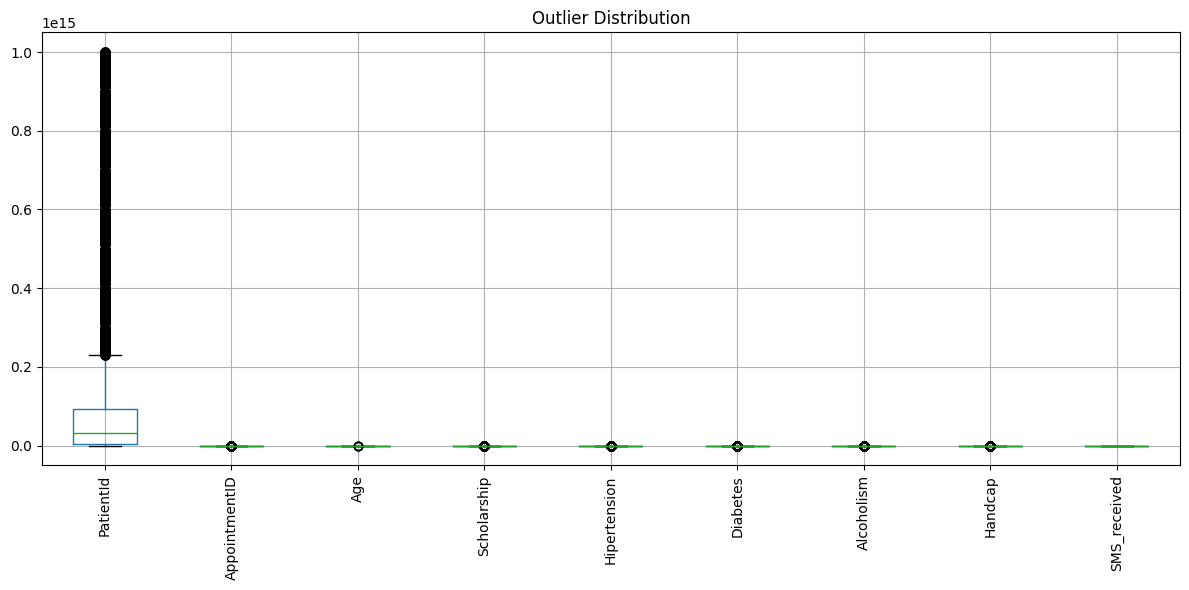

In [13]:
plt.figure(figsize=(12, 6))
numeric_df.boxplot()
plt.title("Outlier Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


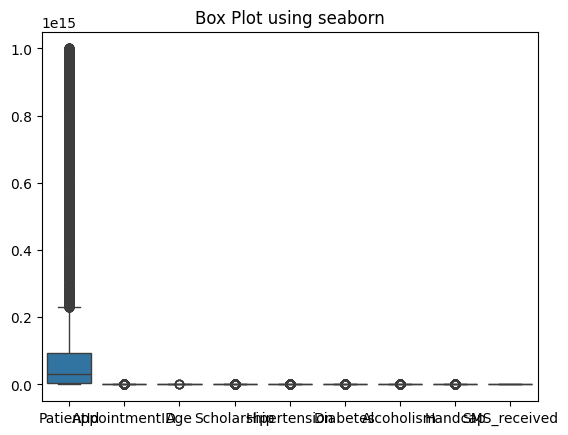

In [14]:
sns.boxplot(data)
plt.title('Box Plot using seaborn')
plt.show()